In [ ]:
# DAY 6 : Machine Learning
# GOAl — AT RISK Classifier model ,,,,,,,,,, Predict if a student is at academic risk based purely on their emotional state

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/cleaned/student_lifestyle_engineered.csv')

In [3]:
print(df.shape)

(1000, 26)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

features = ['stress_level',
            'anxiety_score',
            'sleep_hours',
            'mood_rating',
            'sleep_debt',
            'stress_sleep_ratio',
            'state_score']

target = 'at_risk'

X = df[features]
y = df[target]

print(f"Features selected : {len(features)}")
print(f"\nAt risk students : {y.sum()}")
print(f"Safe students    : {(y==0).sum()}")

Features selected : 7

At risk students : 68
Safe students    : 932


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Data split complete!")
print(f"Training rows : {X_train.shape[0]}")
print(f"Testing rows  : {X_test.shape[0]}")

Data split complete!
Training rows : 800
Testing rows  : 200


In [6]:
model = RandomForestClassifier(
    n_estimators=100,   # 100 trees voting together
    random_state=42
)

model.fit(X_train, y_train)
print(" Model trained!")

 Model trained!


In [7]:
y_pred = model.predict(X_test)

print("=" * 45)
print("MODEL RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred, 
      target_names=['Safe', 'At Risk']))

MODEL RESULTS
              precision    recall  f1-score   support

        Safe       1.00      0.98      0.99       187
     At Risk       0.81      1.00      0.90        13

    accuracy                           0.98       200
   macro avg       0.91      0.99      0.94       200
weighted avg       0.99      0.98      0.99       200



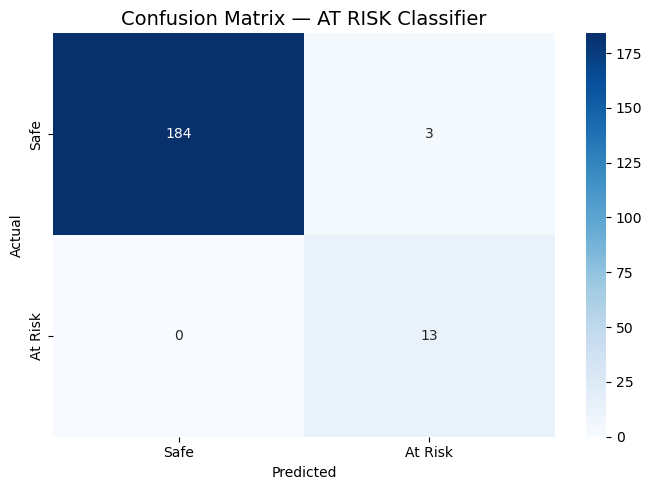

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'At Risk'],
            yticklabels=['Safe', 'At Risk'])
plt.title('Confusion Matrix — AT RISK Classifier', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/08_confusion_matrix.png')
plt.show()


C:\Users\rahul\AppData\Local\Temp\ipykernel_2556\3401122656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature',


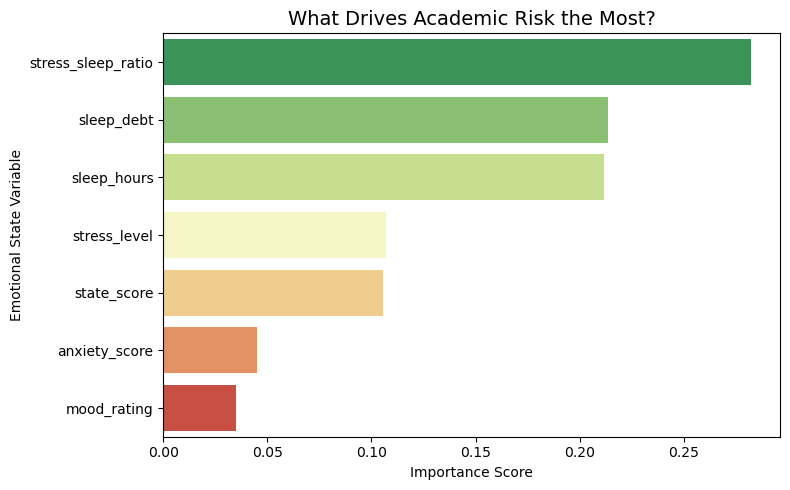

           Feature  Importance
stress_sleep_ratio    0.282152
        sleep_debt    0.213678
       sleep_hours    0.211577
      stress_level    0.106850
       state_score    0.105698
     anxiety_score    0.045175
       mood_rating    0.034870


In [9]:
#Which emotional state variable matters most?
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature', 
            palette='RdYlGn_r')
plt.title('What Drives Academic Risk the Most?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Emotional State Variable')
plt.tight_layout()
plt.savefig('../reports/figures/09_feature_importance.png')
plt.show()

print(importance.to_string(index=False))